# Parallelism — Publication Plots
Reads from `fig_parallelism_plot1_source_data.csv` and `fig_parallelism_plot2_source_data.csv`
and reproduces 2 parallelism plots

This notebook is plotting-only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter, MultipleLocator
from pathlib import Path

# ── Global rcParams (project standard) ───────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['scatter.edgecolors'] = 'none'
plt.rcParams['axes.linewidth']     = 0.6

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

COLOR_CSF    = okabe_ito['black']
COLOR_PLASMA = okabe_ito['blue']
COLOR_STD    = okabe_ito['reddish purple']

In [2]:
# ── Load source data ──────────────────────────────────────────────────────────
df_samples = pd.read_csv('parallelism_plot1_source_data.csv')
df_std     = pd.read_csv('parallelism_plot2_source_data.csv')

print(f"Sample rows : {len(df_samples)}")
print(f"Std rows    : {len(df_std)}")

Sample rows : 88
Std rows    : 11


## Plot 1
Log2-log2 concentration vs dilution for each sample.
CSF samples coloured separately from plasma.

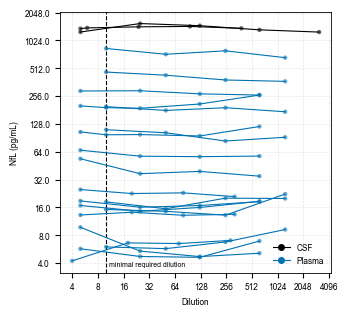

In [3]:
### PUBLICATION PLOT 1

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))

# ── Axis range from data ──────────────────────────────────────────────────────
all_dil  = df_samples['dilution'].values
all_conc = df_samples['SLR; log10(x); exc_std0; ct; mean_ng/L'].values

dil_tickvals  = np.arange(np.floor(np.log2(all_dil.min())),  np.ceil(np.log2(all_dil.max()))  + 1)
conc_tickvals = np.arange(np.floor(np.log2(all_conc.min())), np.ceil(np.log2(all_conc.max())) + 1)
dil_ticktext  = [str(int(2**v)) for v in dil_tickvals]
conc_ticktext = [str(round(2**v, 2)) for v in conc_tickvals]

# ── Plot each sample ──────────────────────────────────────────────────────────
for sid, grp in df_samples.groupby('sample_id'):
    grp = grp.sort_values('dilution')
    x = np.log2(grp['dilution'].values)
    y = np.log2(grp['SLR; log10(x); exc_std0; ct; mean_ng/L'].values)
    color = COLOR_CSF if grp['sample_type'].iloc[0] == 'CSF' else COLOR_PLASMA
    ax.plot(x, y, linewidth=0.8, color=color, zorder=3)
    ax.scatter(x, y, color=color, s=10, alpha=0.6, edgecolors='none', zorder=4)

# ── Vertical dashed line at dilution = 10 ────────────────────────────────────
ax.axvline(x=np.log2(10), color='black', linestyle='--', linewidth=0.8)
y_min, y_max = ax.get_ylim()
ax.text(
    np.log2(10) + 0.1, y_min + 0.02 * (y_max - y_min),
    'minimal required dilution',
    color='black', fontsize=5, ha='left', va='bottom'
)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Dilution')
ax.set_ylabel('NfL (pg/mL)')
ax.set_xticks(dil_tickvals)
ax.set_xticklabels(dil_ticktext)
ax.set_yticks(conc_tickvals)
ax.set_yticklabels(conc_ticktext)
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=COLOR_CSF,    lw=0.8, marker='o', markerfacecolor=COLOR_CSF,    markersize=4, label='CSF'),
    Line2D([0], [0], color=COLOR_PLASMA, lw=0.8, marker='o', markerfacecolor=COLOR_PLASMA, markersize=4, label='Plasma'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False)

# ── Panel label ───────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig('parallelism_plot1.svg', dpi=300, bbox_inches='tight')
plt.show()

## Plot 2
Cq vs dilution (log-scale x, inverted) showing:
- Sample linear fits in blue (reconstructed from m, c per sample)
- Standard curve segments in orange
- Reference slope band (m = -3.32)

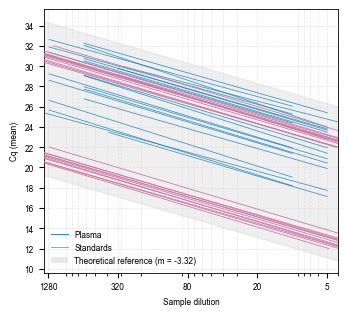

In [4]:
### PUBLICATION PLOT 2

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))

# ── Sample linear fits ────────────────────────────────────────────────────────
for sid, grp in df_samples.groupby('sample_id'):
    dil_vals = grp['dilution'].values
    m = grp['m'].iloc[0]
    c = grp['c'].iloc[0]
    x_fit = np.logspace(np.log10(dil_vals.min()), np.log10(dil_vals.max()), 200)
    log10_inv_dil = np.log10(100 / x_fit)
    y_fit = m * log10_inv_dil + c
    ax.plot(x_fit, y_fit, color=COLOR_PLASMA, linewidth=0.6, alpha=0.7, zorder=6)

# ── Standard curve segments ───────────────────────────────────────────────────
for _, row in df_std.iterrows():
    try:
        d1 = 100 / (10 ** row['ct12'])
        d2 = 100 / (10 ** row['ct22(lower)'])
        d3 = 100 / (10 ** row['ct22(upper)'])
        d4 = 100 / (10 ** row['ct32'])
        ax.plot([d1, d2], [12, 22], color=COLOR_STD, linewidth=0.6, zorder=6)
        ax.plot([d3, d4], [22, 32], color=COLOR_STD, linewidth=0.6, zorder=6)
    except (KeyError, ValueError):
        pass

# ── Reference slope band (m = -3.32) ─────────────────────────────────────────
m_ref   = -3.32
x_left  = 4
x_right = 1400
x_ref   = np.logspace(np.log10(x_left), np.log10(x_right), 300)

y_upper_left = 26
c_upper = y_upper_left - m_ref * np.log10(100 / x_left)
y_upper = m_ref * np.log10(100 / x_ref) + c_upper

y_lower_left = 10.8
c_lower = y_lower_left - m_ref * np.log10(100 / x_left)
y_lower = m_ref * np.log10(100 / x_ref) + c_lower

ax.fill_between(x_ref, y_lower, y_upper,
                color='lightgrey', alpha=0.35, zorder=2)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xlim(x_left, x_right)
ax.invert_xaxis()

custom_ticks = [5, 20, 80, 320, 1280]
ax.set_xticks(custom_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.set_xticklabels([str(t) for t in custom_ticks])
ax.yaxis.set_major_locator(MultipleLocator(2))

ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
ax.set_xlabel('Sample dilution')
ax.set_ylabel('Cq (mean)')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=COLOR_PLASMA, lw=0.6, label='Plasma'),
    Line2D([0], [0], color=COLOR_STD,    lw=0.6, label='Standards'),
    mpl.patches.Patch(facecolor='lightgrey', alpha=0.5,
                      label='Theoretical reference (m = -3.32)'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False)

# ── Panel label ───────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig('parallelism_plot2.svg', dpi=300, bbox_inches='tight')
plt.show()